In [4]:
# Homework 6 Template
# G. Besla & R. Li

In [7]:
# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# my modules
from ReadFile import Read
# Step 1: modify CenterOfMass so that COM_P now takes a parameter specifying 
# by how much to decrease RMAX instead of a factor of 2
from CenterOfMass2 import CenterOfMass



In [23]:
def OrbitCOM(galaxy, start, end, n=5):
    """function that loops over all the desired snapshots to compute the COM pos and vel as a function of time.
    inputs:
        • galaxy the name of the galaxy, e.g. “MW”
        • start the number of the first snapshot to be read in.
        • end the number of the last snapshot to be read in.
        • n an integer indicating the intervals over which you will return the COM.
          
    outputs: 
    """
    
    # compose the filename for output
    fileout = "Orbit_" + galaxy + ".txt"
    #  set tolerance and VolDec for calculating COM_P in CenterOfMass
    # for M33 that is stripped more, use different values for VolDec
    delta = 0.1
    if (galaxy == "M33"):
        volDec = 4
    else:
        volDec = 2
        
    
    # generate the snapshot id sequence 
    # it is always a good idea to also check if the input is eligible (not required)
    snap_ids = np.arange(start, end+1, n)
    if (len(snap_ids) == 0):
        print("Empty array because the start and stop values are invalid")
        return (1) # C standard for indicating errors
        
    
    # initialize the array for orbital info: t, x, y, z, vx, vy, vz of COM
    orbit = np.zeros([len(snap_ids), 7])
    # The number of rows are the snap ids and the number of columns are basically 
    # the parameters described above.
    
    # a for loop 
    for i, snap_id in enumerate(snap_ids): # loop over files
        
        # compose the data filename (be careful about the folder)
        filename = ilbl = "000" + str(snap_id)
        # remove all but the last 3 digits
        ilbl = ilbl[-3:]
        filename="%s_"%(galaxy) + ilbl + ".txt"
        filename = './' + galaxy + "/" + filename

        # Initialize an instance of CenterOfMass class, using disk particles
        COM_Object = CenterOfMass(filename, 2)

        # Store the COM pos and vel. Remember that now COM_P required VolDec
        COM_p = COM_Object.COM_P(delta, volDec)
        COM_v = COM_Object.COM_V(COM_p[0],COM_p[1], COM_p[2])
        #print(COM_p)
            
        # store the time, pos, vel in ith element of the orbit array,  without units (.value) 
        # note that you can store 
        # a[i] = var1, *tuple(array1)
        orbit[i, 0] = (COM_Object.time.value)/1000
        orbit[i, 1] = COM_p[0].value
        orbit[i, 2] = COM_p[1].value
        orbit[i, 3] = COM_p[2].value
        orbit[i, 4] = COM_v[0].value
        orbit[i, 5] = COM_v[1].value
        orbit[i, 6] = COM_v[2].value
        
        
        # print snap_id to see the progress
        print(snap_id)
        
    # write the data to a file
    # we do this because we don't want to have to repeat this process 
    # this code should only have to be called once per galaxy.
    np.savetxt(fileout, orbit, fmt = "%11.3f"*7, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))

In [66]:
# Recover the orbits and generate the COM files for each galaxy
# read in 800 snapshots in intervals of n=5
# Note: This might take a little while - test your code with a smaller number of snapshots first! 
OrbitCOM("MW", 0, 800)
OrbitCOM("M31", 0, 800)
OrbitCOM("M33", 0, 800)

0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395
400
405
410
415
420
425
430
435
440
445
450
455
460
465
470
475
480
485
490
495
500
505
510
515
520
525
530
535
540
545
550
555
560
565
570
575
580
585
590
595
600
605
610
615
620
625
630
635
640
645
650
655
660
665
670
675
680
685
690
695
700
705
710
715
720
725
730
735
740
745
750
755
760
765
770
775
780
785
790
795
800
0
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395
400
405
410
415
420
425
430
435
440
445
450
455
460
465
470
475
480
485
490
495


In [68]:
# Read in the data files for the orbits of each galaxy that you just created
# headers:  t, x, y, z, vx, vy, vz
# using np.genfromtxt

filename = "Orbit_" + "MW" + ".txt"
data = np.genfromtxt(filename,dtype=None,names=True,skip_header=0)
mw_time = data['t'] 
mw_pos = np.column_stack((data['x'], data['y'], data['z']))
mw_v = np.column_stack((data['vx'], data['vy'], data['vz']))


In [70]:
filename = "Orbit_" + "M31" + ".txt"
data = np.genfromtxt(filename,dtype=None,names=True,skip_header=0)
m31_time = data['t'] 
m31_pos = np.column_stack((data['x'], data['y'], data['z']))
m31_v = np.column_stack((data['vx'], data['vy'], data['vz']))

In [72]:
filename = "Orbit_" + "M33" + ".txt"
data = np.genfromtxt(filename,dtype=None,names=True,skip_header=0)
m33_time = data['t'] 
m33_pos = np.column_stack((data['x'], data['y'], data['z']))
m33_v = np.column_stack((data['vx'], data['vy'], data['vz']))

In [74]:
# function to compute the magnitude of the difference between two vectors 
# You can use this function to return both the relative position and relative velocity for two 
# galaxies over the entire orbit  
def vector_magnitude(vec1, vec2):
    return np.linalg.norm(vec1 - vec2, axis=1)

In [76]:
# Determine the magnitude of the relative position and velocities 

# of MW and M31
sep_mw_m31 = vector_magnitude(mw_pos, m31_pos)
vel_mw_m31 = vector_magnitude(mw_v, m31_v)
# of M33 and M31
sep_m33_m31 = vector_magnitude(m33_pos, m31_pos)
vel_m33_m31 = vector_magnitude(m33_v, m31_v)

In [85]:
m33_time - m31_time

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

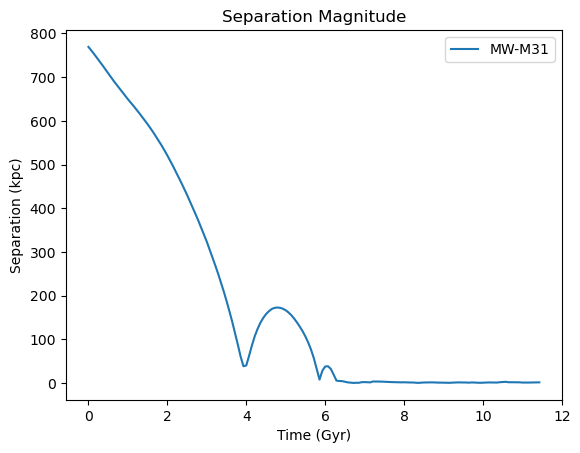

In [117]:
# Plot the Orbit of the galaxies 
plt.plot(mw_time, sep_mw_m31, label="MW-M31")

plt.xlabel("Time (Gyr)")
plt.ylabel("Separation (kpc)")
plt.title("Separation Magnitude")
plt.legend()

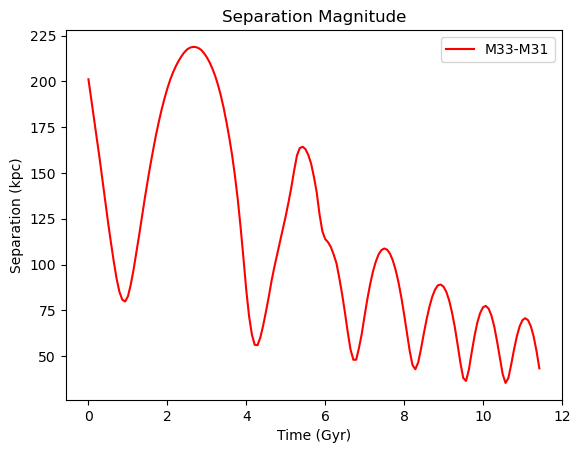

In [119]:
# Plot the Orbit of the galaxies 
#################################
# Plot results

plt.plot(m31_time, sep_m33_m31, label="M33-M31", color='r')
plt.xlabel("Time (Gyr)")
plt.ylabel("Separation (kpc)")
plt.title("Separation Magnitude")
plt.legend()



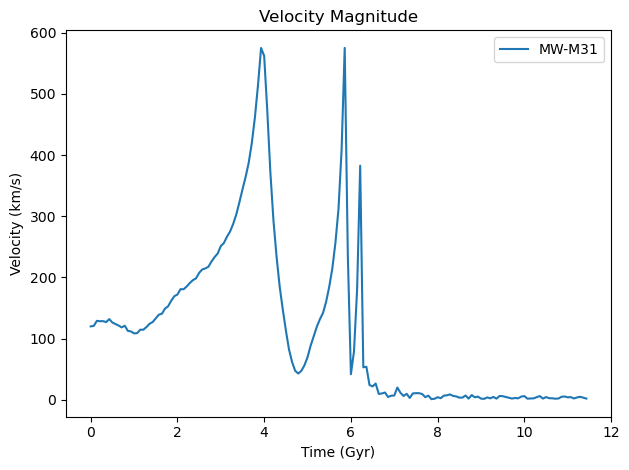

In [111]:
plt.plot(m31_time, vel_mw_m31, label="MW-M31")
plt.xlabel("Time (Gyr)")
plt.ylabel("Velocity (km/s)")
plt.title("Velocity Magnitude")
plt.legend()

plt.tight_layout()
plt.show()


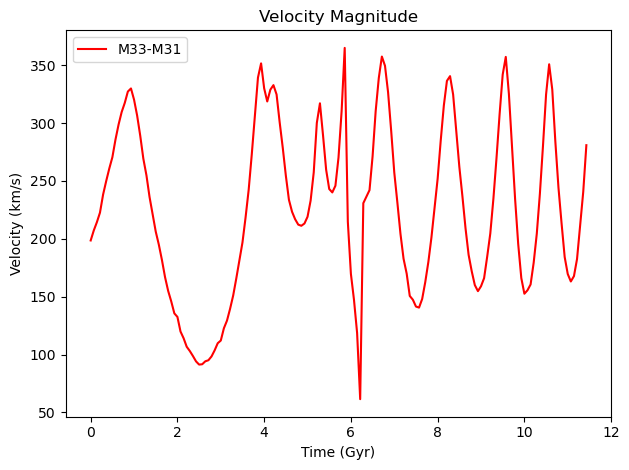

In [113]:
# Plot the orbital velocities of the galaxies 
#################################

#plt.plot(m31_time, vel_mw_m31, label="MW-M31 Velocity", color='b')
plt.plot(m31_time, vel_m33_m31, label="M33-M31", color='r')
plt.xlabel("Time (Gyr)")
plt.ylabel("Velocity (km/s)")
plt.title("Velocity Magnitude")
plt.legend()

plt.tight_layout()
plt.show()


In [54]:
filename = ilbl = "000" + str(5)
# remove all but the last 3 digits
ilbl = ilbl[-3:]
filename="%s_"%("MW") + ilbl + ".txt"
filename = './' + "MW" + "/" + filename
filename
time, total, data = Read(filename)   
data

array([(1., 0.0078997, 179.483  ,  226.904  , 310.46   ,   45.1504,  37.3357,  27.3536),
       (1., 0.0078997,  22.3077 , -121.962  , 118.659  ,  176.798 , 111.272 , -14.0319),
       (1., 0.0078997, 465.638  , -250.159  , 347.144  ,  -11.1411,  81.4407, -25.8651),
       ...,
       (3., 0.0002001,  -1.57815,    2.98095,  -1.08823, -109.055 , 159.353 , -57.6959),
       (3., 0.0002001,  -3.97274,   14.0859 ,  -2.64192,  116.455 , 105.807 , -71.4557),
       (3., 0.0002001,  -1.62828,    3.26776,  -1.92469, -105.628 , 240.912 , 309.033 )],
      dtype=[('type', '<f8'), ('m', '<f8'), ('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('vx', '<f8'), ('vy', '<f8'), ('vz', '<f8')])

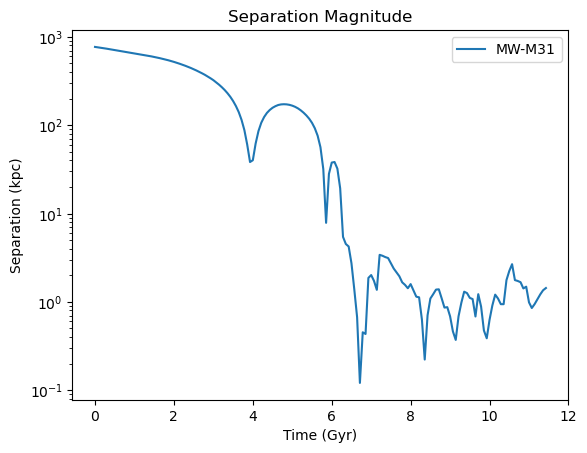

In [127]:
plt.plot(mw_time, sep_mw_m31, label="MW-M31")
plt.yscale('log')
plt.xlabel("Time (Gyr)")
plt.ylabel("Separation (kpc)")
plt.title("Separation Magnitude")
plt.legend()

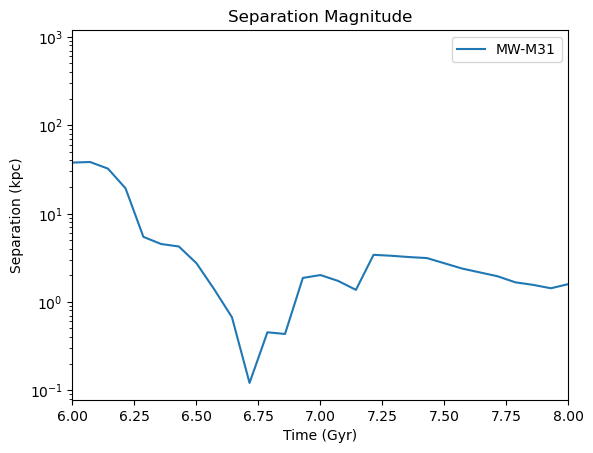

In [131]:
plt.plot(mw_time, sep_mw_m31, label="MW-M31")
plt.yscale('log')
plt.xlabel("Time (Gyr)")
plt.ylabel("Separation (kpc)")
plt.title("Separation Magnitude")
plt.xlim(6, 8)
plt.legend()


(0.0, 12.0)

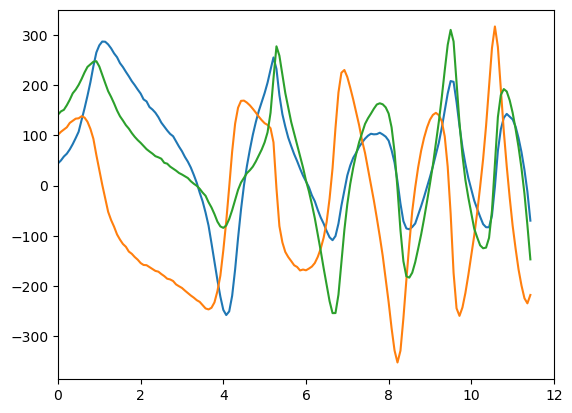

In [155]:
plt.plot(m33_time, m33_v)
plt.xlim(0, 12)

## Questions





## 1. How many close encounters will the MW and M31 experience in the future?
### Twice, one would be about 4 Gyr and the second one would be about 5.9 - 6 Gyr

## 2. How is the time evolution of the separation and relative velocity related?
### Just by looking at the plots, we see that as we have lesser seperation, the relative velocity increases. This is because of the inverse relationship between the gravitational force and seperation squared. Thus, then the velocity is at the maximum.

## 4. When do M31 and the MW merge? (you might need to zoom in on the plot - try a log y axis). What happens to M33’s orbit when they merge?
### They merge approximately at 6.25 Gyrs. We see that the velocity is have frequent full rotations, so the orbit might be smaller.

## 5. BONUS: what is roughly the decay rate of M33’s orbit after 6 Gyr (ratio of the differ- ence between two successive apocenters and the orbital period; you don’t need to be precise). If this rate is constant, how long will it take M33 to merge with the combined MW+M31 remnant if it is at a distance of 75 kpc?

### About 4 Gyrs, 18.75 Gyrs

In [157]:
print(75/4)

18.75
